<a href="https://colab.research.google.com/github/Alister03USA/Portfolio-and-Projects/blob/main/ML_Ops_Airbnbs_Price_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import gradio as gr
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# 1. Data Processing and Cleaning


In [ ]:
# Read the datasets
listings = pd.read_csv('listings.csv')

# Data cleaning function
def clean_listings_data(df):
    """
    Cleans the Airbnb listings dataframe by handling missing values,
    dropping empty columns, and formatting dates.

    Parameters:
    The raw listings dataframe.

    Returns:
    The cleaned dataframe.
    """
    # Create a copy to avoid modifying the original dataframe directly
    df = df.copy()

    # 1. Drop neighbourhood_group (completely empty, 0 non-null values)
    df.drop(columns=['neighbourhood_group'], inplace=True, errors='ignore')

    # 2. Convert last_review from string to a datetime object
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

    # 3. Handle Missing Reviews (NaN means 0 reviews)
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

    # 4. Handle Missing Target Variable (Price)
    df.dropna(subset=['price'], inplace=True)

    # 5. Handle missing licenses and host names
    df['license'] = df['license'].fillna('Unlicensed')
    df['host_name'] = df['host_name'].fillna('Unknown')

    # 6. Convert last_review to days_since_last_review for the machine learning models
    reference_date = df['last_review'].max()
    df['days_since_last_review'] = (reference_date - df['last_review']).dt.days
    df['days_since_last_review'] = df['days_since_last_review'].fillna(-1)
    df.drop(columns=['last_review'], inplace=True)

    return df

listings_clean = clean_listings_data(listings)

print("--- Cleaned Listings Info ---")
listings_clean.info()
print("-" * 30)

# Remove extreme outliers (Any price above $1616, which is the 99th percentile)
listings_clean = listings_clean[listings_clean['price'] <= 1616]

--- Cleaned Listings Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 5795 entries, 0 to 7779
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5795 non-null   int64  
 1   name                            5795 non-null   object 
 2   host_id                         5795 non-null   int64  
 3   host_name                       5795 non-null   object 
 4   neighbourhood                   5795 non-null   object 
 5   latitude                        5795 non-null   float64
 6   longitude                       5795 non-null   float64
 7   room_type                       5795 non-null   object 
 8   price                           5795 non-null   float64
 9   minimum_nights                  5795 non-null   int64  
 10  number_of_reviews               5795 non-null   int64  
 11  reviews_per_month               5795 non-null   float64
 12  calculate

Price Summary Statistics:
count    5737.000000
mean      230.348091
std       201.657373
min        29.000000
25%       104.000000
50%       169.000000
75%       280.000000
max      1614.000000
Name: price, dtype: float64

Price Percentiles:
90th Percentile: $ 448.40000000000055
95th Percentile: $ 605.1999999999998
99th Percentile: $ 1085.0


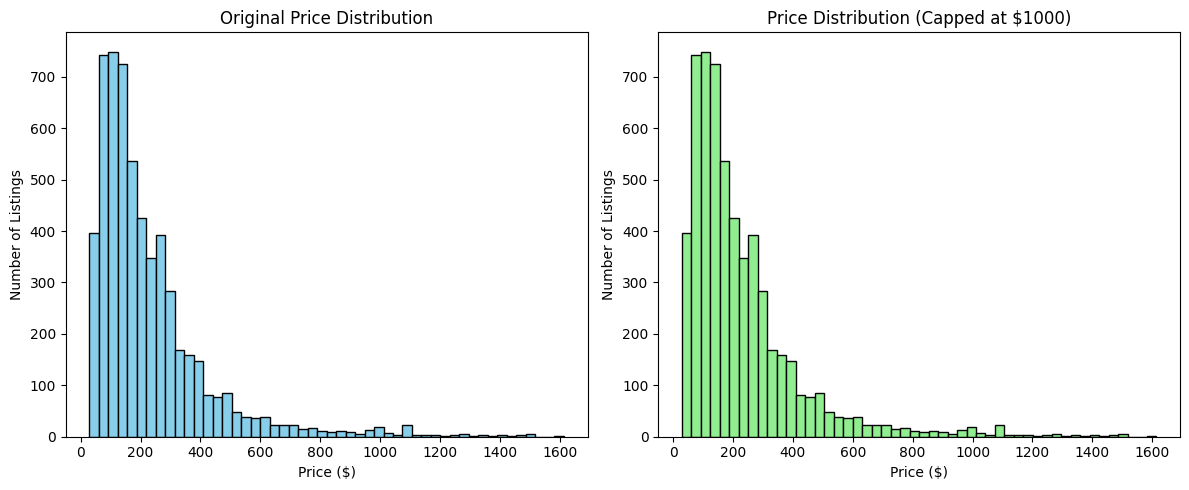

In [ ]:
# 1. Analyze Price Distribution
print("Price Summary Statistics:")
print(listings_clean['price'].describe())

print("\nPrice Percentiles:")
print("90th Percentile: $", listings_clean['price'].quantile(0.90))
print("95th Percentile: $", listings_clean['price'].quantile(0.95))
print("99th Percentile: $", listings_clean['price'].quantile(0.99))

# 2. Plot the distribution (Raw vs Capped)
plt.figure(figsize=(12, 5))

# Plot 1: Raw Prices (Shows the extreme skew)
plt.subplot(1, 2, 1)
plt.hist(listings_clean['price'], bins=50, color='skyblue', edgecolor='black')
plt.title("Original Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

# Plot 2: Prices under $1,616 which is the 99th percentile
plt.subplot(1, 2, 2)
filtered_prices = listings_clean[listings_clean['price'] <= 1616]['price']
plt.hist(filtered_prices, bins=50, color='lightgreen', edgecolor='black')
plt.title("Price Distribution (Capped at $1000)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.tight_layout()

# Remove outliers (Any price above $1000, it consists of several outliers such as $40,000 and $50,000)

# 2. GEOSPATIAL FEATURE ENGINEERING

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculates distance between two GPS coordinates in miles."""
    R = 3958.8
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Add distance to Union Square (Downtown SF proxy)
listings_clean['dist_to_city_center'] = haversine_distance(
    listings_clean['latitude'], listings_clean['longitude'], 37.7879, -122.4074
)

# Create a lookup dictionary for the Gradio App (Average distance per neighborhood)
avg_dist_per_hood = listings_clean.groupby('neighbourhood')['dist_to_city_center'].mean().to_dict()

# 3. Feature Engineering and Train/ Test Split

In [ ]:
df = listings_clean.copy()

# Drop Identifiers and Free-Text Columns
cols_to_drop = ['id', 'name', 'host_id', 'host_name', 'license']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# One-Hot Encode Categorical Variables
df_encoded = pd.get_dummies(df, columns=['room_type', 'neighbourhood'], drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Train / Validation Split (80% Training, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Data: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Validation Data: {X_val.shape[0]} rows, {X_val.shape[1]} features")
print(X_train.head())

Training Data: 4589 rows, 49 features
Validation Data: 1148 rows, 49 features
       latitude   longitude  minimum_nights  number_of_reviews  \
75    37.759810 -122.418800              30                135   
1612  37.791830 -122.450000              30                  1   
5169  37.797786 -122.413289              30                  5   
5012  37.723637 -122.460412              30                  2   
2560  37.791700 -122.420530             365                  0   

      reviews_per_month  calculated_host_listings_count  availability_365  \
75                 0.78                               2               282   
1612               0.02                               1               358   
5169               0.23                               1               251   
5012               0.15                               3                82   
2560               0.00                              50               365   

      number_of_reviews_ltm  days_since_last_review  dist_to_c

# 4. Feature Selection & Hyperparameter Tuning





In [ ]:
print("1. Running Feature Selection")
# Train a quick initial model to find feature importance
rf_initial = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_initial.fit(X_train, y_train)

# Extract Top 15 Features to prevent overfitting
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_initial.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_15_features = importances.head(15)['Feature'].tolist()

# Reduce datasets to only the top 15 features
X_train_reduced = X_train[top_15_features]
X_val_reduced = X_val[top_15_features]

print("2. Hyperparameter Tuning on reduced features")
# Define the 'Hyperparameters' we want to test
param_grid = {
    'n_estimators': [100, 300, 500],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2]
}

# Fine-Tune the Model using Randomized Search
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_reduced, y_train)
best_rf = rf_random.best_estimator_

print(f"\nBest Hyperparameters Found: {rf_random.best_params_}")

1. Running Feature Selection
2. Hyperparameter Tuning on reduced features
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Hyperparameters Found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1}


# 5. Model Comparison & Preliminary Results
Metrics:


*   Mean Absolute Error: measure absolute error magnitude
*   Root Mean Squared Error: Highlights large error by squaring them before averaging
*   R-squared: proportion of variance explained by the model





In [ ]:
print("\n2. Training models for comparison...")

# Initialize the Scaler (REQUIRED for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Tuned Random Forest
best_rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1

)


# XGBoost Model
# learning_rate=0.05 and max_depth=6 are good starting points for this dataset size
best_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)


models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Random Forest (Tuned)": best_rf,
    "SVM (SVR)": SVR(kernel='rbf', C=1000, epsilon=1), # Scaled data will be used in loop
    "XGBoost": best_xgb
}

results_list = []
for name, model in models.items():
    if name == "Random Forest (Tuned)":
        model.fit(X_train_reduced, y_train)
        preds = model.predict(X_val_reduced)
    elif name == "SVM (SVR)":
        # We use the scaled versions of our features for SVM
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_val)

    results_list.append({
        "Model": name,
        "MAE ($)": round(mean_absolute_error(y_val, preds), 2),
        "RMSE ($)": round(np.sqrt(mean_squared_error(y_val, preds)), 2),
        "R-Squared": round(r2_score(y_val, preds), 4)
    })

print("PRELIMINARY RESULTS TABLE")
print(pd.DataFrame(results_list).to_markdown(index=False))


2. Training models for comparison...
PRELIMINARY RESULTS TABLE
| Model                        |   MAE ($) |   RMSE ($) |   R-Squared |
|:-----------------------------|----------:|-----------:|------------:|
| Linear Regression (Baseline) |    114.22 |     175.61 |      0.2193 |
| Gradient Boosting            |     91.47 |     150    |      0.4304 |
| Random Forest (Tuned)        |     83.18 |     142.23 |      0.4879 |
| SVM (SVR)                    |     88.58 |     162.63 |      0.3304 |
| XGBoost                      |     87.42 |     147.03 |      0.4527 |


# Fine-tuned XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the XGBoost model
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# 2. Define the parameter grid
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# 3. Setup Randomized Search with 5-Fold Cross Validation
# n_iter=20 means we test 20 random combinations
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error', # We want to minimize MAE
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning with 5-Fold CV...")
xgb_search.fit(X_train, y_train)

# 4. Results
print(f"Best Parameters: {xgb_search.best_params_}")
print(f"Best CV MAE: {-xgb_search.best_score_:.2f}")


# 5. Evaluate the best model on the Validation Set
best_xgb = xgb_search.best_estimator_
final_preds = best_xgb.predict(X_val)

Starting Hyperparameter Tuning with 5-Fold CV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.9}
Best CV MAE: 81.49


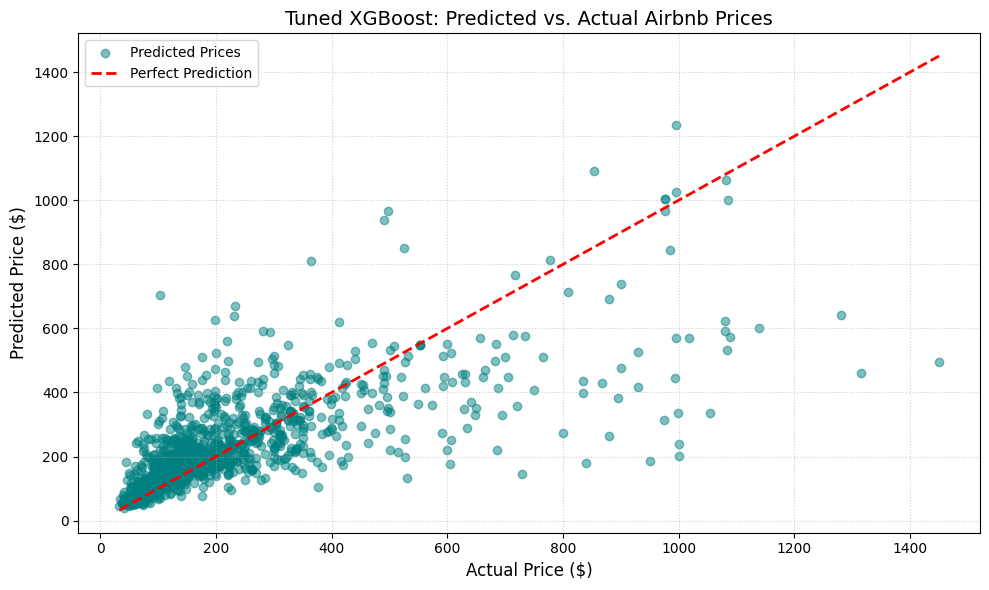

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the plot
plt.figure(figsize=(10, 6))

# 2. Scatter plot of Actual vs. Predicted
# Using alpha=0.5 helps visualize data density
plt.scatter(y_val, final_preds, alpha=0.5, color='teal', label='Predicted Prices')

# 3. Add the "Perfect Prediction" line (y = x)
# This represents where the predictions would fall if they were 100% accurate
max_val = max(max(y_val), max(final_preds))
min_val = min(min(y_val), min(final_preds))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

# 4. Formatting
plt.title('Tuned XGBoost: Predicted vs. Actual Airbnb Prices', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Show and/or Save
plt.tight_layout()
plt.show()

# 6. Visuals


/tmp/ipykernel_7300/4053824800.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')


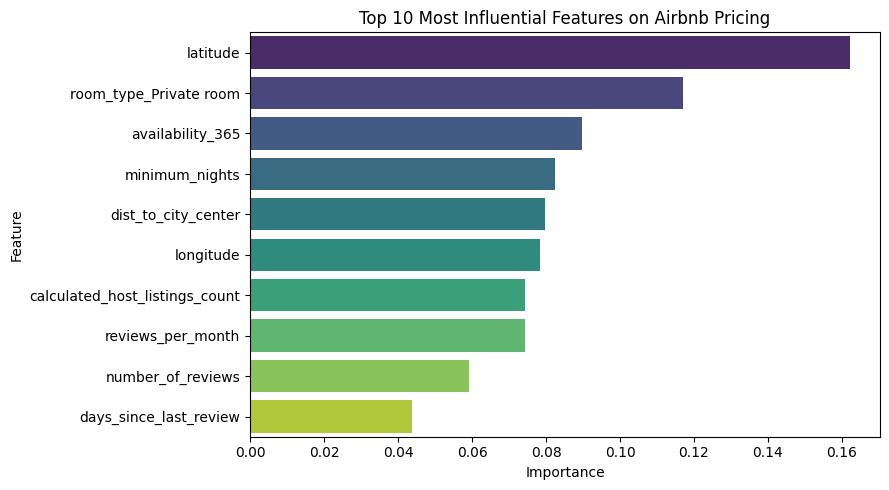

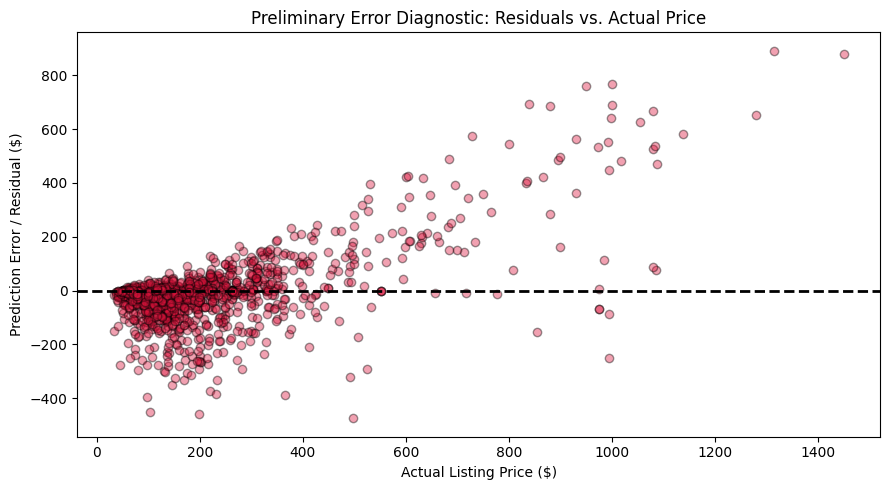

In [ ]:
# Chart A: Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')
plt.title('Top 10 Most Influential Features on Airbnb Pricing')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# Chart B: Error Diagnostic (Residuals)
rf_preds = best_rf.predict(X_val_reduced)
plt.figure(figsize=(9, 5))
plt.scatter(y_val, (y_val - rf_preds), alpha=0.4, color='crimson', edgecolor='k')
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.title('Preliminary Error Diagnostic: Residuals vs. Actual Price')
plt.xlabel('Actual Listing Price ($)')
plt.ylabel('Prediction Error / Residual ($)')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300)
plt.show()

# 7. Gradio UI Web App


In [ ]:
print("Gradio Dashboard")

def predict_airbnb_price(model, feature_columns, new_listing_dict):
    df_new = pd.DataFrame([new_listing_dict])
    df_new = df_new.reindex(columns=feature_columns, fill_value=0)
    return model.predict(df_new)[0]

def smart_stays_dashboard(room_type, neighbourhood, min_nights, reviews, avail_days, host_listings):
    new_listing_dict = {
        f'room_type_{room_type}': 1,
        f'neighbourhood_{neighbourhood}': 1,
        'minimum_nights': min_nights,
        'number_of_reviews': reviews,
        'reviews_per_month': 1.5,
        'availability_365': avail_days,
        'calculated_host_listings_count': host_listings,
        'dist_to_city_center': avg_dist_per_hood.get(neighbourhood, 3.0)
    }

    # Predict using the reduced columns that the tuned model expects
    optimal_price = predict_airbnb_price(best_rf, X_train_reduced.columns, new_listing_dict)
    price_output = f"${optimal_price:.2f} per night"

    # Map visualizer
    map_df = listings_clean[listings_clean['neighbourhood'] == neighbourhood]
    if len(map_df) == 0:
        map_df = listings_clean

    fig = px.scatter_mapbox(
        map_df, lat="latitude", lon="longitude", color="price",
        hover_name="room_type", hover_data=["price", "minimum_nights"],
        color_continuous_scale=px.colors.sequential.Plasma,
        zoom=12, height=500, title=f"Current Market in {neighbourhood}"
    )
    fig.update_layout(mapbox_style="carto-positron")

    return price_output, fig

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Smart Stays: San Francisco Airbnb Pricing Tool")
    gr.Markdown("Enter the details of your property below to get a data-driven nightly price recommendation, powered by our fine-tuned Random Forest algorithm.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Property Details")
            room_type = gr.Dropdown(choices=['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'], label="Room Type", value='Entire home/apt')
            hoods = ['Mission', 'Western Addition', 'South of Market', 'Bernal Heights', 'Castro/Upper Market', 'North Beach', 'Marina', 'Outer Sunset', 'Nob Hill']
            neighbourhood = gr.Dropdown(choices=hoods, label="Neighborhood", value='Mission')
            min_nights = gr.Slider(minimum=1, maximum=30, value=2, step=1, label="Minimum Nights")
            reviews = gr.Slider(minimum=0, maximum=500, value=10, step=1, label="Total Reviews")
            avail_days = gr.Slider(minimum=0, maximum=365, value=365, step=1, label="Availability (Days per year)")
            host_listings = gr.Slider(minimum=1, maximum=20, value=1, step=1, label="Host's Total Listings")

            predict_btn = gr.Button("Calculate Optimal Price", variant="primary")

        with gr.Column():
            gr.Markdown("### AI Recommendation")
            price_display = gr.Textbox(label="Recommended Nightly Price", text_align="center")
            map_display = gr.Plot(label="Local Market Competition")

    predict_btn.click(
        fn=smart_stays_dashboard,
        inputs=[room_type, neighbourhood, min_nights, reviews, avail_days, host_listings],
        outputs=[price_display, map_display]
    )

demo.launch(share=True, debug=True)

Gradio Dashboard


/tmp/ipykernel_7300/1910305443.py:39: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d4fb2ecf3645b9fe22.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
